<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/CNN-model/CNN-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone --branch CNN-model --single-branch https://github.com/dokunoale/chagas.git
%cd chagas
# Carica librerie installate
!pip install wfdb -q
!pip install gdown -q

# Aggiungi solo la root del progetto (src)
import sys
sys.path.append('/content/chagas/src')

# Importa tutto dai moduli
from preprocessing import tf_dataset_loader
from models import libraries, functions, split_dataset
from models.CNN import build_model

# Importa simboli specifici (se vuoi)
from models.libraries import *
from models.functions import *
from models.split_dataset import *
from models.CNN.build_model import *


Cloning into 'chagas'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 119 (delta 36), reused 42 (delta 20), pack-reused 45 (from 1)
Receiving objects: 100% (119/119), 33.36 KiB | 1.39 MiB/s, done.
Resolving deltas: 100% (41/41), done.
/content/chagas
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.0 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
cudf-cu12 25.2.1 requires pandas<2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

url = "https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q dataset.zip -d ./dataset

Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_
From (redirected): https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_&confirm=t&uuid=9769a680-9c8b-4ac6-b266-4b6823a1e16c
To: /content/chagas/dataset.zip
100%|██████████| 435M/435M [00:02<00:00, 196MB/s]


In [3]:
X_pos, y_pos = tf_dataset_loader.load_dataset('/content/chagas/dataset/preprocessed/positives')
X_neg, y_neg = tf_dataset_loader.load_dataset('/content/chagas/dataset/preprocessed/negatives')

In [4]:
#Uniamo i positivi e i negativi
X = np.concatenate([X_pos, X_neg], axis=0)
y = np.concatenate([y_pos, y_neg], axis=0)

# Facciamo lo shuffle
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

# Riordinamento di X e y con gli stessi indici
X = X[indices]
y = y[indices]

In [5]:
#SPLIT DEL DATASET
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)

In [6]:
# mettiamo le etichette sottoforma di 0 e 1
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print(np.unique(y_train))

[0 1]


# Primo modello: usiamo la BCE

In [7]:
model1 = build_cnn_ecg_model()

#compiliamo il modello
model1.compile(optimizer='adam',
              loss=BinaryCrossentropy(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("1_CNN")

cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

history1 = model1.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    class_weight=class_weights,
                    callbacks=callback)



Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.6540 - auc: 0.6649 - loss: 0.6651
Epoch 1: val_auc improved from -inf to 0.74041, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 103s 723ms/step - accuracy: 0.6542 - auc: 0.6652 - loss: 0.6649 - val_accuracy: 0.7707 - val_auc: 0.7404 - val_loss: 0.5547 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.7074 - auc: 0.7485 - loss: 0.5924
Epoch 2: val_auc improved from 0.74041 to 0.76001, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 142s 728ms/step - accuracy: 0.7075 - auc: 0.7485 - loss: 0.5924 - val_accuracy: 0.7363 - val_auc: 0.7600 - val_loss: 0.5523 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.7149 - auc: 0.7690 - loss: 0.5761
Epoch 3: val_auc improved from 0.76001 to 0.77176, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 142s 730ms/step - accuracy: 0.7150 - auc: 0.7690 - loss: 0.5762 - val_accuracy: 0.6508 - val_auc: 0.7718 - val_loss: 0.6319 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.7255 - auc: 0.7895 - loss: 0.5666
Epoch 4: val_auc improved from 0.77176 to 0.80140, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 137s 690ms/step - accuracy: 0.7255 - auc: 0.7895 - loss: 0.5666 - val_accuracy: 0.7700 - val_auc: 0.8014 - val_loss: 0.5159 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.7495 - auc: 0.8157 - loss: 0.5330
Epoch 5: val_auc improved from 0.80140 to 0.81582, saving model to 1_CNN_best_model.h5


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 142s 668ms/step - accuracy: 0.8406 - auc: 0.9322 - loss: 0.3083 - val_accuracy: 0.8443 - val_auc: 0.9403 - val_loss: 0.3122 - learning_rate: 0.0010
Epoch 17/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.8516 - auc: 0.9420 - loss: 0.2799
Epoch 17: val_auc did not improve from 0.94031
134/134 ━━━━━━━━━━━━━━━━━━━━ 141s 666ms/step - accuracy: 0.8516 - auc: 0.9419 - loss: 0.2800 - val_accuracy: 0.8408 - val_auc: 0.9326 - val_loss: 0.3301 - learning_rate: 0.0010
Epoch 18/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.8503 - auc: 0.9381 - loss: 0.2972
Epoch 18: val_auc did not improve from 0.94031
134/134 ━━━━━━━━━━━━━━━━━━━━ 147s 705ms/step - accuracy: 0.8504 - auc: 0.9381 - loss: 0.2971 - val_accuracy: 0.7707 - val_auc: 0.9342 - val_loss: 0.5631 - learning_rate: 0.0010
Epoch 19/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.8505 - auc: 0.9416 - loss: 0.2890
Epoch 19: val_auc improved from 0.94031 to 0.94121, saving model t

134/134 ━━━━━━━━━━━━━━━━━━━━ 142s 704ms/step - accuracy: 0.8505 - auc: 0.9416 - loss: 0.2890 - val_accuracy: 0.8022 - val_auc: 0.9412 - val_loss: 0.3960 - learning_rate: 0.0010
Epoch 20/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.8619 - auc: 0.9516 - loss: 0.2632
Epoch 20: val_auc did not improve from 0.94121
134/134 ━━━━━━━━━━━━━━━━━━━━ 91s 678ms/step - accuracy: 0.8619 - auc: 0.9515 - loss: 0.2633 - val_accuracy: 0.8485 - val_auc: 0.9354 - val_loss: 0.2999 - learning_rate: 0.0010
Epoch 21/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.8646 - auc: 0.9458 - loss: 0.2736
Epoch 21: val_auc improved from 0.94121 to 0.95304, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 141s 672ms/step - accuracy: 0.8645 - auc: 0.9458 - loss: 0.2735 - val_accuracy: 0.8394 - val_auc: 0.9530 - val_loss: 0.3278 - learning_rate: 0.0010
Epoch 22/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.8650 - auc: 0.9503 - loss: 0.2613
Epoch 22: val_auc did not improve from 0.95304
134/134 ━━━━━━━━━━━━━━━━━━━━ 141s 666ms/step - accuracy: 0.8650 - auc: 0.9503 - loss: 0.2613 - val_accuracy: 0.8212 - val_auc: 0.9461 - val_loss: 0.3710 - learning_rate: 0.0010
Epoch 23/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.8648 - auc: 0.9547 - loss: 0.2507
Epoch 23: val_auc did not improve from 0.95304
134/134 ━━━━━━━━━━━━━━━━━━━━ 145s 689ms/step - accuracy: 0.8647 - auc: 0.9546 - loss: 0.2508 - val_accuracy: 0.8254 - val_auc: 0.9494 - val_loss: 0.3355 - learning_rate: 0.0010
Epoch 24/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.8540 - auc: 0.9501 - loss: 0.2611
Epoch 24: val_auc did not improve from 0.95304
134/134 ━━━━━━━━━━━

134/134 ━━━━━━━━━━━━━━━━━━━━ 141s 704ms/step - accuracy: 0.8696 - auc: 0.9581 - loss: 0.2440 - val_accuracy: 0.8527 - val_auc: 0.9556 - val_loss: 0.3028 - learning_rate: 5.0000e-04
Epoch 26/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.8725 - auc: 0.9620 - loss: 0.2266
Epoch 26: val_auc did not improve from 0.95565
134/134 ━━━━━━━━━━━━━━━━━━━━ 140s 691ms/step - accuracy: 0.8726 - auc: 0.9620 - loss: 0.2266 - val_accuracy: 0.8597 - val_auc: 0.9498 - val_loss: 0.2819 - learning_rate: 5.0000e-04
Epoch 27/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.8898 - auc: 0.9654 - loss: 0.2167
Epoch 27: val_auc did not improve from 0.95565
134/134 ━━━━━━━━━━━━━━━━━━━━ 142s 693ms/step - accuracy: 0.8897 - auc: 0.9654 - loss: 0.2167 - val_accuracy: 0.8422 - val_auc: 0.9523 - val_loss: 0.3614 - learning_rate: 5.0000e-04
Epoch 28/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.8914 - auc: 0.9681 - loss: 0.2130
Epoch 28: val_auc improved from 0.95565 to 0.95853, sa

134/134 ━━━━━━━━━━━━━━━━━━━━ 144s 709ms/step - accuracy: 0.8914 - auc: 0.9681 - loss: 0.2131 - val_accuracy: 0.8640 - val_auc: 0.9585 - val_loss: 0.3219 - learning_rate: 5.0000e-04
Epoch 29/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.8836 - auc: 0.9646 - loss: 0.2196
Epoch 29: val_auc did not improve from 0.95853
134/134 ━━━━━━━━━━━━━━━━━━━━ 93s 689ms/step - accuracy: 0.8836 - auc: 0.9646 - loss: 0.2196 - val_accuracy: 0.8597 - val_auc: 0.9548 - val_loss: 0.3089 - learning_rate: 5.0000e-04
Epoch 30/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.8889 - auc: 0.9688 - loss: 0.2133
Epoch 30: val_auc did not improve from 0.95853
134/134 ━━━━━━━━━━━━━━━━━━━━ 138s 664ms/step - accuracy: 0.8889 - auc: 0.9688 - loss: 0.2133 - val_accuracy: 0.8555 - val_auc: 0.9544 - val_loss: 0.3309 - learning_rate: 5.0000e-04


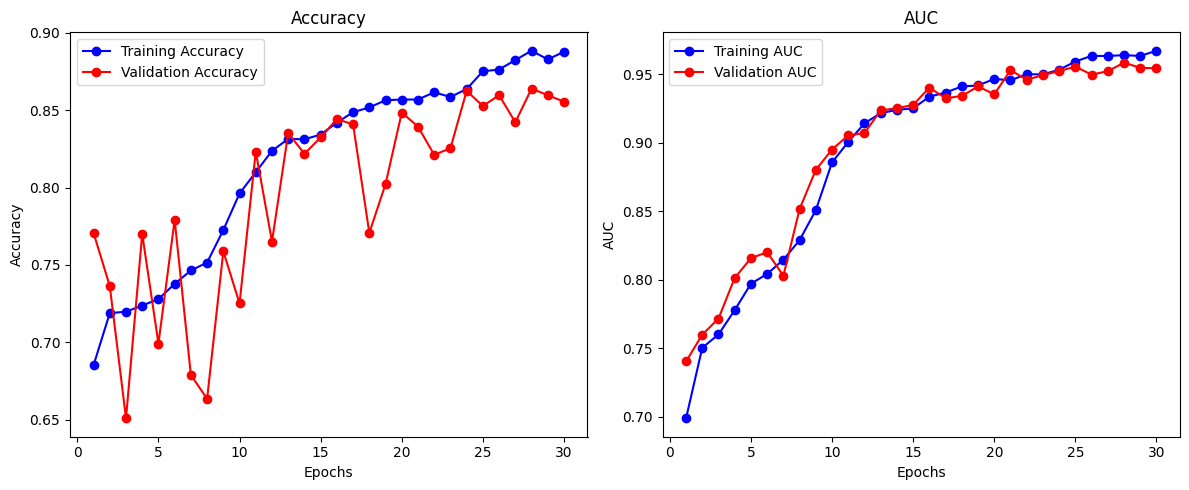

In [8]:
#visualizziamo l'andamento delle metriche durante l'addestramento
plot_training_metrics(history1)

In [15]:
!git pull origin CNN-model
from models import functions
importlib.reload(functions)

From https://github.com/dokunoale/chagas
 * branch            CNN-model  -> FETCH_HEAD
Already up to date.


<module 'models.functions' from '/content/chagas/src/models/functions.py'>

In [17]:
#Facciamo le predizioni
y_pred_proba = model1.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)
print(f"Soglia ottimale: {optimal_threshold}")

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step
Soglia ottimale: 0.764
Soglia ottimale: 0.763981819152832


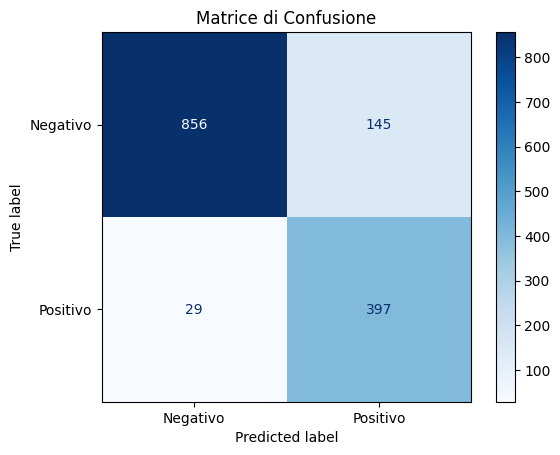

In [22]:
#Calcoliamo la matrice di confusione e la visualizziamo
from models import functions
importlib.reload(functions)
from models.functions import show_confusion_matrix

cm1 = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm1)

In [23]:
#Vediamo i risultati
acc1 = accuracy_score(y_test, y_pred_binary)
auc1 = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc1:.3f}")
print(f"AUC: {auc1:.3f}")

class_report1 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report1)

Accuracy: 0.878
AUC: 0.956
              precision    recall  f1-score   support

    Negativo       0.97      0.86      0.91      1001
    Positivo       0.73      0.93      0.82       426

    accuracy                           0.88      1427
   macro avg       0.85      0.89      0.86      1427
weighted avg       0.90      0.88      0.88      1427



# Secondo modello: usiamo la focal loss

In [26]:
!git pull origin CNN-model
from models import functions
importlib.reload(functions)

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 463 bytes | 231.00 KiB/s, done.
From https://github.com/dokunoale/chagas
 * branch            CNN-model  -> FETCH_HEAD
   f3ff1ee..c730401  CNN-model  -> origin/CNN-model
Updating f3ff1ee..c730401
Fast-forward
 src/models/functions.py | 1 +
 1 file changed, 1 insertion(+)


<module 'models.functions' from '/content/chagas/src/models/functions.py'>

In [27]:
model2 = build_cnn_ecg_model()

#compiliamo il modello
model2.compile(optimizer='adam',
              loss=focal_loss(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("2_CNN")

cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

history2 = model2.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    class_weight=class_weights,
                    callbacks=callback)

Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.7120 - auc: 0.6577 - loss: 0.0515
Epoch 1: val_auc improved from -inf to 0.75272, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 97s 679ms/step - accuracy: 0.7122 - auc: 0.6580 - loss: 0.0515 - val_accuracy: 0.7167 - val_auc: 0.7527 - val_loss: 0.0356 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.7492 - auc: 0.7556 - loss: 0.0333
Epoch 2: val_auc improved from 0.75272 to 0.79392, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 147s 720ms/step - accuracy: 0.7492 - auc: 0.7555 - loss: 0.0333 - val_accuracy: 0.7384 - val_auc: 0.7939 - val_loss: 0.0314 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.7519 - auc: 0.7803 - loss: 0.0316
Epoch 3: val_auc improved from 0.79392 to 0.80148, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 140s 702ms/step - accuracy: 0.7519 - auc: 0.7802 - loss: 0.0316 - val_accuracy: 0.7840 - val_auc: 0.8015 - val_loss: 0.0290 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.7643 - auc: 0.8082 - loss: 0.0298
Epoch 4: val_auc improved from 0.80148 to 0.81598, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 140s 686ms/step - accuracy: 0.7643 - auc: 0.8081 - loss: 0.0298 - val_accuracy: 0.7819 - val_auc: 0.8160 - val_loss: 0.0274 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.7549 - auc: 0.8168 - loss: 0.0297
Epoch 5: val_auc improved from 0.81598 to 0.83473, saving model to 2_CNN_best_model.h5


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 146s 691ms/step - accuracy: 0.8189 - auc: 0.9101 - loss: 0.0176 - val_accuracy: 0.8247 - val_auc: 0.9069 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 12/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.8416 - auc: 0.9217 - loss: 0.0160
Epoch 12: val_auc improved from 0.90691 to 0.91351, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 92s 689ms/step - accuracy: 0.8415 - auc: 0.9217 - loss: 0.0160 - val_accuracy: 0.8338 - val_auc: 0.9135 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 13/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.8142 - auc: 0.9131 - loss: 0.0174
Epoch 13: val_auc did not improve from 0.91351
134/134 ━━━━━━━━━━━━━━━━━━━━ 144s 702ms/step - accuracy: 0.8143 - auc: 0.9131 - loss: 0.0174 - val_accuracy: 0.8289 - val_auc: 0.9102 - val_loss: 0.0180 - learning_rate: 0.0010
Epoch 14/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.8344 - auc: 0.9215 - loss: 0.0156
Epoch 14: val_auc improved from 0.91351 to 0.91490, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 137s 669ms/step - accuracy: 0.8344 - auc: 0.9215 - loss: 0.0156 - val_accuracy: 0.8303 - val_auc: 0.9149 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 15/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.8457 - auc: 0.9303 - loss: 0.0132
Epoch 15: val_auc did not improve from 0.91490
134/134 ━━━━━━━━━━━━━━━━━━━━ 150s 728ms/step - accuracy: 0.8457 - auc: 0.9303 - loss: 0.0132 - val_accuracy: 0.7798 - val_auc: 0.9068 - val_loss: 0.0400 - learning_rate: 0.0010
Epoch 16/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.8367 - auc: 0.9315 - loss: 0.0146
Epoch 16: val_auc did not improve from 0.91490
134/134 ━━━━━━━━━━━━━━━━━━━━ 138s 695ms/step - accuracy: 0.8367 - auc: 0.9315 - loss: 0.0146 - val_accuracy: 0.8177 - val_auc: 0.9079 - val_loss: 0.0278 - learning_rate: 0.0010
Epoch 17/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.8490 - auc: 0.9375 - loss: 0.0134
Epoch 17: val_auc improved from 0.91490 to 0.92498, saving model t

134/134 ━━━━━━━━━━━━━━━━━━━━ 140s 677ms/step - accuracy: 0.8490 - auc: 0.9375 - loss: 0.0134 - val_accuracy: 0.8380 - val_auc: 0.9250 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 18/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8508 - auc: 0.9291 - loss: 0.0148
Epoch 18: val_auc did not improve from 0.92498
134/134 ━━━━━━━━━━━━━━━━━━━━ 145s 701ms/step - accuracy: 0.8508 - auc: 0.9292 - loss: 0.0148 - val_accuracy: 0.8254 - val_auc: 0.9139 - val_loss: 0.0266 - learning_rate: 0.0010
Epoch 19/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.8621 - auc: 0.9433 - loss: 0.0115
Epoch 19: val_auc did not improve from 0.92498
134/134 ━━━━━━━━━━━━━━━━━━━━ 90s 675ms/step - accuracy: 0.8621 - auc: 0.9433 - loss: 0.0115 - val_accuracy: 0.8275 - val_auc: 0.9221 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 20/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.8620 - auc: 0.9483 - loss: 0.0108
Epoch 20: val_auc did not improve from 0.92498
134/134 ━━━━━━━━━━━━

134/134 ━━━━━━━━━━━━━━━━━━━━ 165s 845ms/step - accuracy: 0.8706 - auc: 0.9483 - loss: 0.0112 - val_accuracy: 0.8534 - val_auc: 0.9364 - val_loss: 0.0140 - learning_rate: 5.0000e-04
Epoch 22/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.8671 - auc: 0.9519 - loss: 0.0109
Epoch 22: val_auc did not improve from 0.93645
134/134 ━━━━━━━━━━━━━━━━━━━━ 123s 707ms/step - accuracy: 0.8671 - auc: 0.9519 - loss: 0.0109 - val_accuracy: 0.8541 - val_auc: 0.9363 - val_loss: 0.0151 - learning_rate: 5.0000e-04
Epoch 23/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.8871 - auc: 0.9617 - loss: 0.0083
Epoch 23: val_auc did not improve from 0.93645
134/134 ━━━━━━━━━━━━━━━━━━━━ 94s 696ms/step - accuracy: 0.8871 - auc: 0.9616 - loss: 0.0083 - val_accuracy: 0.8429 - val_auc: 0.9327 - val_loss: 0.0155 - learning_rate: 5.0000e-04
Epoch 24/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.8834 - auc: 0.9614 - loss: 0.0087
Epoch 24: val_auc did not improve from 0.93645
134/134 

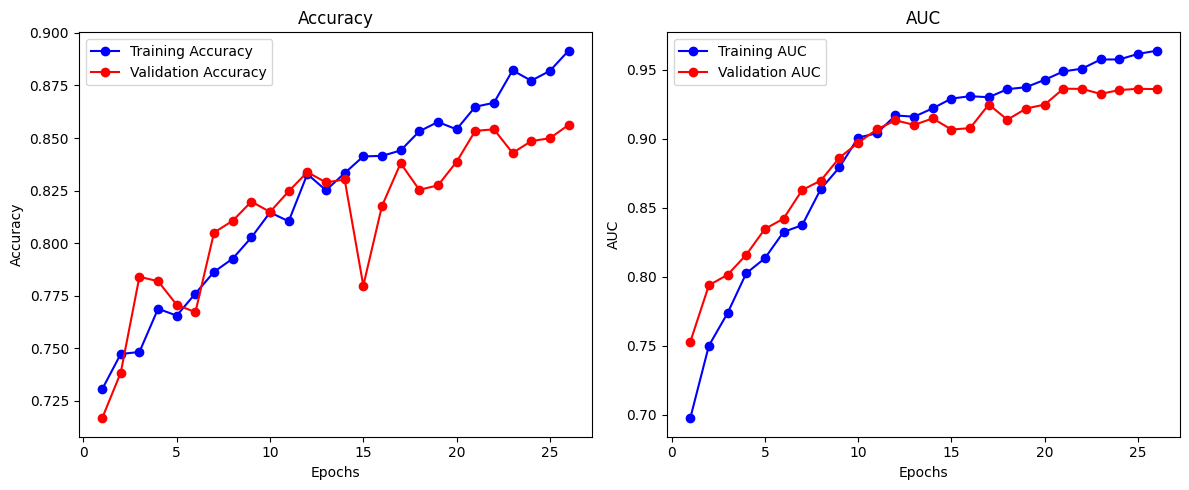

In [28]:
#visualizziamo l'andamento delle metriche durante l'addestramento
plot_training_metrics(history2)

In [30]:
#Facciamo le predizioni
y_pred_proba = model2.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)
print(f"Soglia ottimale: {optimal_threshold}")

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step
Soglia ottimale: 0.258
Soglia ottimale: 0.2577112317085266


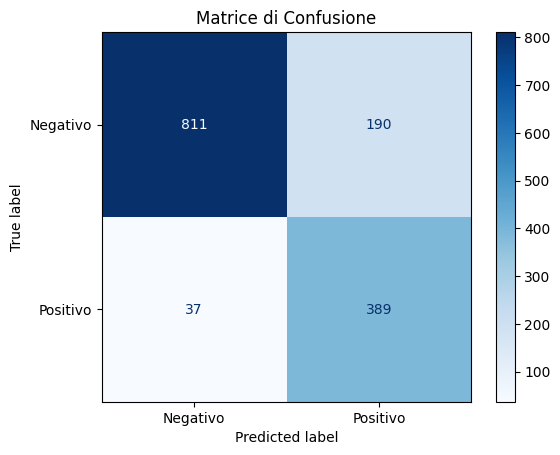

In [32]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm2 = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm2)

In [33]:
#Vediamo i risultati
acc2 = accuracy_score(y_test, y_pred_binary)
auc2 = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc2:.3f}")
print(f"AUC: {auc2:.3f}")

class_report2 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report2)

Accuracy: 0.841
AUC: 0.936
              precision    recall  f1-score   support

    Negativo       0.96      0.81      0.88      1001
    Positivo       0.67      0.91      0.77       426

    accuracy                           0.84      1427
   macro avg       0.81      0.86      0.83      1427
weighted avg       0.87      0.84      0.85      1427



In [46]:
!git pull origin CNN-model
from models import functions
from models.functions import compare_classification_reports

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 840 bytes | 420.00 KiB/s, done.
From https://github.com/dokunoale/chagas
 * branch            CNN-model  -> FETCH_HEAD
   c4fab2c..b4124a2  CNN-model  -> origin/CNN-model
Updating c4fab2c..b4124a2
Fast-forward
 src/models/functions.py | 46 +++++++++++++++++-----------------------------
 1 file changed, 17 insertions(+), 29 deletions(-)


In [47]:
print(f"ACCURACY = modello 1: {acc1:.3f}, modello 2: {acc2:.3f}")
print(f"AUC = modello 1: {auc1:.3f}, modello 2: {auc2:.3f}")

ACCURACY = modello 1: 0.878, modello 2: 0.841
AUC = modello 1: 0.956, modello 2: 0.936


#  Terzo modello: utilizzo dell'attenzione

In [52]:
from models.CNN import build_model_with_attention
from models.CNN.build_model_with_attention import *